# WikiArt Painter Classification — Training Notebook (Colab)

**Deep Learning — Course Project**

This notebook trains models on the **pre-cleaned, pre-split** `wikiart_split` dataset.

## Strategy
1. **Phase 1 — Feature Extraction**: Freeze the entire EfficientNetB0 backbone, train only the new classification head.
2. **Phase 2 — Fine-tuning**: Unfreeze the top layers of the backbone, train end-to-end at a lower learning rate.

---
## 0. Setup & Data Loading

In [14]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [15]:
# Import Libraries
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path

import tensorflow as tf
import keras
from keras import layers, callbacks, optimizers
from keras.applications import VGG16
from keras.applications.vgg16 import preprocess_input

from keras.callbacks import EarlyStopping, ModelCheckpoint

# Learning Rate Scheduler is a common callback to reduce the learning rate when the validation loss plateaus, which can help the model converge better.
from keras.callbacks import ReduceLROnPlateau

from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import cv2

In [16]:
# Load Datasets
# TODO: adjust this path to where wikiart_split is stored in your Drive

#!cp -r /content/drive/MyDrive/wikiart_split /content/

!cp /content/drive/MyDrive/wikiart_split.zip /content/
!unzip -q /content/wikiart_split.zip -d /content/
SPLIT_DIR = Path('/content/wikiart_split')

#SPLIT_DIR   = Path('/content/drive/MyDrive/wikiart_split')

In [17]:
# Global Configuration

IMG_SIZE    = (224, 224)   # VGG16 native input size
BATCH_SIZE  = 32
NUM_CLASSES = 23
AUTOTUNE    = tf.data.AUTOTUNE

EPOCHS_FE   = 20           # Feature Extraction epochs
EPOCHS_FT   = 20           # Fine-Tuning epochs
LR_FE       = 1e-3         # Learning rate — Feature Extraction
LR_FT       = 1e-5         # Lower learning rate for Fine-Tuning

train_dir = SPLIT_DIR / 'train'
val_dir   = SPLIT_DIR / 'val'
test_dir  = SPLIT_DIR / 'test'

print('Keras  :', keras.__version__)
print('TF     :', tf.__version__)
print('GPU    :', tf.config.list_physical_devices('GPU') or 'None - CPU mode')
print('Split  :', SPLIT_DIR)
print('Exists :', SPLIT_DIR.exists())

Keras  : 3.13.2
TF     : 2.19.0
GPU    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
Split  : /content/wikiart_split
Exists : True


In [18]:
# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

---
## 1. tf.data Pipeline

In [19]:
# ── Load datasets from pre-split folders ──────────────────────────────────
train_ds_raw = keras.utils.image_dataset_from_directory(
    train_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    verbose=False
)

val_ds = keras.utils.image_dataset_from_directory(
    val_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

test_ds_raw = keras.utils.image_dataset_from_directory(
    test_dir,
    label_mode='categorical',
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE,
    interpolation='bilinear',
    shuffle=False,
    verbose=False
)

class_names = train_ds_raw.class_names
print(f'Classes ({len(class_names)}): {class_names}')

print(f'Train batches: {len(train_ds_raw)}')
print(f'Val batches  : {len(val_ds)}')
print(f'Test batches : {len(test_ds_raw)}')

Classes (23): ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']
Train batches: 313
Val batches  : 63
Test batches : 42


In [ ]:
# O código seguinte é igual ao da Maria só que usando o VGG16

In [20]:
# ── Apply augmentation + VGG16 preprocessing ───────────────────────
def apply_augmentation(img, label):
    #img = color_spatial_aug(img, training=True)
    #img = tf.clip_by_value(img, 0.0, 255.0)
    img = keras.applications.vgg16.preprocess_input(img)
    #img = random_erasing(img, training=True)
    return img, label

def apply_preprocessing(img, label):
    img = keras.applications.vgg16.preprocess_input(img)
    return img, label

train_ds = (
    train_ds_raw
    .shuffle(buffer_size=1000, seed=SEED)
    .map(apply_augmentation, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

val_ds = (
    val_ds
    .map(apply_preprocessing, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

test_ds = (
    test_ds_raw
    .map(apply_preprocessing, num_parallel_calls=AUTOTUNE)
    .prefetch(AUTOTUNE)
)

print(f'Train batches: {len(train_ds)}')
print(f'Val batches  : {len(val_ds)}')
print(f'Test batches : {len(test_ds)}')

Train batches: 313
Val batches  : 63
Test batches : 42


In [ ]:
# Tentei correr o código a seguir mas ou tem algo de errado ou o dataset é demasiado grande, pq demorou imenso tempo a correr
# e não cnsegui acabar

In [ ]:
# Visualise a batch of augmented training samples
sample_imgs, sample_labels = next(iter(train_ds))
sample_display = np.clip((sample_imgs[:8].numpy() + 1.0) / 2.0, 0, 1)

fig, axes = plt.subplots(2, 4, figsize=(14, 6))
for ax, img, lbl in zip(axes.flatten(), sample_display, sample_labels[:8]):
    ax.imshow(img)
    ax.set_title(class_names[np.argmax(lbl)].replace('_', ' '), fontsize=8)
    ax.axis('off')
plt.suptitle('Augmented Training Samples', fontsize=12)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

## 3. VGG16 Architecture

**VGG16** (Simonyan & Zisserman, 2014) is characterised by:
- 13 convolutional layers (blocks of 2–3 convolutions with 3×3 filters)
- 3 fully-connected layers (4096 → 4096 → 1000)
- ~138 million total parameters

We replace the original classifier with a custom head adapted to our number of classes.

In [ ]:
# A função criada a seguir é parecida com a função build model da maria mas associada ao VGG16 e feita como o claude aconselhou

In [21]:
def build_vgg16_feature_extraction(num_classes):
    """
    VGG16 with the convolutional base fully frozen.
    Only the custom classifier head is trained.
    """
    base_model = VGG16(
        weights='imagenet',
        include_top=False,          # Remove the original classifier
        input_shape=(*IMG_SIZE, 3)
    )

    # Freeze the entire convolutional base
    base_model.trainable = False

    # Custom classifier head
    inputs  = keras.Input(shape=(*IMG_SIZE, 3))
    x       = base_model(inputs, training=False) # guarantees the base model is in inference mode (e.g., BatchNorm layers)
    x       = layers.GlobalAveragePooling2D()(x)
    x       = layers.Dense(256, activation='relu')(x)
    x       = layers.BatchNormalization()(x) # o chat aconselhou a acrescentar
    x       = layers.Dropout(0.5)(x)

    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name="VGG16_FeatureExtraction")
    return model, base_model


model_fe, base_model = build_vgg16_feature_extraction(NUM_CLASSES)

trainable     = sum(tf.size(w).numpy() for w in model_fe.trainable_weights)
non_trainable = sum(tf.size(w).numpy() for w in model_fe.non_trainable_weights)
print(f"Trainable parameters:     {trainable:,}")
print(f"Non-trainable parameters: {non_trainable:,}")
model_fe.summary()

Trainable parameters:     137,751
Non-trainable parameters: 14,715,200


Model: "VGG16_FeatureExtraction"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ vgg16 (Functional)              │ (None, 7, 7, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,852,951 (56.66 MB)

 Trainable params: 137,751 (538.09 KB)

 Non-trainable params: 14,715,200 (56.13 MB)

## 4. Approach 1 — Feature Extraction

The convolutional base is **completely frozen** — VGG16 acts as a fixed feature extractor.  
Only the custom classifier head is trained.

In [24]:
def make_metrics():
    return [
        keras.metrics.CategoricalAccuracy(name='accuracy'),
        keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_accuracy'),
    ]

model_fe.compile(
    optimizer = optimizers.Adam(learning_rate=LR_FE),
    loss ='categorical_crossentropy',
    metrics = make_metrics()
)

# Forma mais simples usando apenas ReduceLROnPlateau. A seguir já vem uma mais robusta usando também o EarlyStopping e o ModelCheckpoint
callbacks_fe = [
    EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1),
    ModelCheckpoint('best_vgg16_fe.keras', monitor='val_loss', save_best_only=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1) # Adds a learning rate scheduler to reduce the learning rate when the validation loss plateaus, which can help the model converge better.
]

print("=" * 50)
print("Training — Feature Extraction")
print("=" * 50)

Training — Feature Extraction


In [ ]:
history_fe = model_fe.fit(
    train_ds,
    epochs=EPOCHS_FE,
    validation_data=val_ds,
    callbacks=callbacks_fe,
    verbose=1
)

Training — Feature Extraction
Epoch 1/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - accuracy: 0.3266 - loss: 2.6836 - top3_accuracy: 0.5186
Epoch 1: val_loss improved from None to 1.37936, saving model to best_vgg16_fe.keras

Epoch 1: finished saving model to best_vgg16_fe.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 161s 311ms/step - accuracy: 0.4405 - loss: 2.0909 - top3_accuracy: 0.6542 - val_accuracy: 0.6017 - val_loss: 1.3794 - val_top3_accuracy: 0.8021 - learning_rate: 0.0010
Epoch 2/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 195ms/step - accuracy: 0.5953 - loss: 1.4172 - top3_accuracy: 0.8106
Epoch 2: val_loss improved from 1.37936 to 1.22616, saving model to best_vgg16_fe.keras

Epoch 2: finished saving model to best_vgg16_fe.keras
313/313 ━━━━━━━━━━━━━━━━━━━━ 160s 284ms/step - accuracy: 0.6115 - loss: 1.3530 - top3_accuracy: 0.8191 - val_accuracy: 0.6442 - val_loss: 1.2262 - val_top3_accuracy: 0.8321 - learning_rate: 0.0010
Epoch 3/20
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 196ms/step - accuracy: 0.6

In [25]:
cb_early = callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

cb_reduce = callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

cb_ckpt = callbacks.ModelCheckpoint(
    'best_vgg16_phase1.weights.h5',
    monitor='val_loss',
    save_best_only=True,
    save_weights_only=True,
    verbose=0
)

class LRLogger(keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs=None):
        lr = float(self.model.optimizer.learning_rate)
        if logs is not None:
            logs['lr'] = lr

cb_lr = LRLogger()

In [26]:
history_fe = model_fe.fit(
    train_ds,
    epochs=30,
    validation_data=val_ds,
    callbacks=[cb_early, cb_reduce, cb_ckpt, cb_lr],
    verbose=1
)

Epoch 1/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 148s 317ms/step - accuracy: 0.4399 - loss: 2.0923 - top3_accuracy: 0.6544 - val_accuracy: 0.6032 - val_loss: 1.3892 - val_top3_accuracy: 0.8036 - learning_rate: 0.0010 - lr: 0.0010
Epoch 2/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 107s 244ms/step - accuracy: 0.6125 - loss: 1.3498 - top3_accuracy: 0.8180 - val_accuracy: 0.6422 - val_loss: 1.2223 - val_top3_accuracy: 0.8341 - learning_rate: 0.0010 - lr: 0.0010
Epoch 3/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 106s 243ms/step - accuracy: 0.6541 - loss: 1.1443 - top3_accuracy: 0.8590 - val_accuracy: 0.6662 - val_loss: 1.1367 - val_top3_accuracy: 0.8526 - learning_rate: 0.0010 - lr: 0.0010
Epoch 4/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 105s 241ms/step - accuracy: 0.6931 - loss: 1.0243 - top3_accuracy: 0.8816 - val_accuracy: 0.6727 - val_loss: 1.1395 - val_top3_accuracy: 0.8506 - learning_rate: 0.0010 - lr: 0.0010
Epoch 5/30
313/313 ━━━━━━━━━━━━━━━━━━━━ 111s 266ms/step - accuracy: 0.7137 - loss: 0.9459 - top3_accuracy: 0.8945 - 

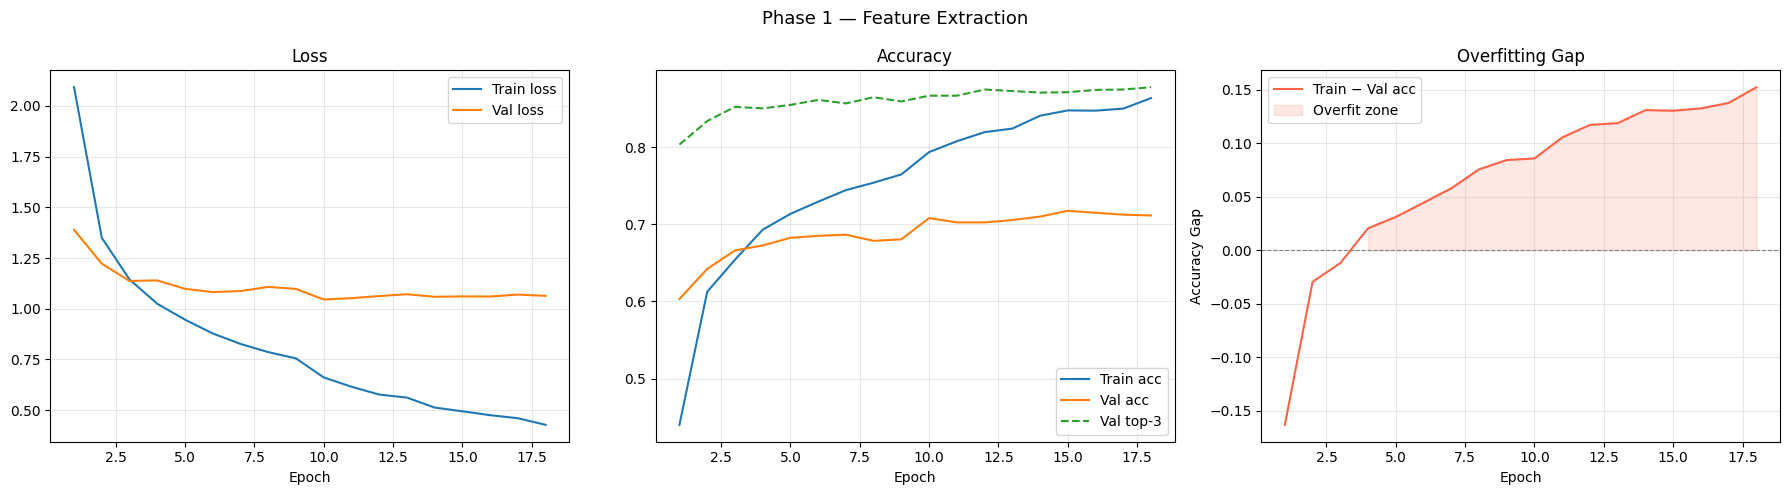

In [27]:
def plot_history(history, title='Training History', offset=0):
    h = history.history
    n = len(h['accuracy'])
    epochs = range(offset + 1, offset + n + 1)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # ── Loss ────────────────────────────────────────────────────
    axes[0].plot(epochs, h['loss'],     label='Train loss')
    axes[0].plot(epochs, h['val_loss'], label='Val loss')
    axes[0].set_title('Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].legend(); axes[0].grid(alpha=0.3)

    # ── Accuracy ─────────────────────────────────────────────────
    axes[1].plot(epochs, h['accuracy'],     label='Train acc')
    axes[1].plot(epochs, h['val_accuracy'], label='Val acc')
    if 'val_top3_accuracy' in h:
        axes[1].plot(epochs, h['val_top3_accuracy'],
                     label='Val top-3', linestyle='--')
    axes[1].set_title('Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].legend(); axes[1].grid(alpha=0.3)

    # ── Overfitting gap ──────────────────────────────────────────
    gap = [tr - va for tr, va in zip(h['accuracy'], h['val_accuracy'])]
    axes[2].plot(epochs, gap, color='tomato', label='Train − Val acc')
    axes[2].axhline(0, color='gray', linestyle='--', linewidth=0.8)
    axes[2].fill_between(epochs, gap, 0,
                          where=[g > 0 for g in gap],
                          alpha=0.15, color='tomato', label='Overfit zone')
    axes[2].set_title('Overfitting Gap')
    axes[2].set_xlabel('Epoch')
    axes[2].set_ylabel('Accuracy Gap')
    axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()

plot_history(history_fe, title='Phase 1 — Feature Extraction')